In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle
import shap
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../../Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [3]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv'

data = read_data(path)
data.head()

months: 5, 6, 7, 8, 9, 10, 
years: 2011, 2012, 2013, 2014, 2018, 2019, 2020, 2021, 
months: 
years: 


,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.0,0.0,0.0,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,178,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.0,0.0,0.0,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,96,9,99.0,30,96,13,13,10,8,9,2,0,164,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.0,0.0,0.0,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,1,96,9,98.0,1,96,13,13,10,8,9,2,0,221,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.0,0.0,0.0,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,88,9,99.0,30,88,13,13,10,8,9,2,0,190,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,0.0,0.0,0.0,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,31,81,30,81.0,50,83,11,10,1,6,6,2,0,206,0,0


In [4]:
data.query('month >= 5 & month <= 10').shape

(10413, 69)

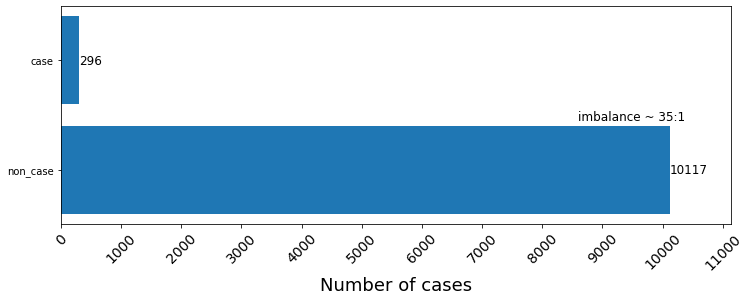

In [5]:
plot_imbalance(data.query('month >= 5 & month <= 10'))

In [6]:
dataset = data.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-05-01,αττικης,αγιας βαρβαρας,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,2.4,26759.0,10925.9,44.75555,0.109613,-0.012625,-0.187337,0.012625,0.138277,-0.005005,-0.207972,0.005005,0.029821,0.009216,0.029016,0.009216,23.35,30.49,16.21,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.259019,3.113871,298.432541,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,168,272,0
1,23.82642,38.00806,2010-05-01,αττικης,αγιας παρασκευης,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,7.9,62157.0,7557.5,44.85879,0.246119,0.081537,-0.195054,-0.081537,0.233828,0.069670,-0.201405,-0.069670,0.021948,0.017464,0.011308,0.017464,21.69,27.93,15.45,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.726824,4.312400,321.631232,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,96,9,99.0,30,96,13,13,10,8,9,2,0,105,272,0
2,23.73031,37.93357,2010-05-01,αττικης,αγιου δημητριου,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,5.0,71747.0,14402.8,44.74465,0.124847,0.005892,-0.182192,-0.005892,0.125107,0.005422,-0.183339,-0.005422,0.009420,0.007833,0.003301,0.007833,22.48,28.45,16.51,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.083028,2.944309,312.558510,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,1,96,9,98.0,1,96,13,13,10,8,9,2,0,179,412,0
3,23.71341,38.04721,2010-05-01,αττικης,αγιων αναργυρων καματερου,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,9.2,61427.0,6833.8,44.83209,0.216806,0.029374,-0.251409,-0.029374,0.229817,0.025588,-0.262820,-0.025588,0.021876,0.009936,0.015521,0.009936,23.25,30.93,15.57,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.899900,5.003595,317.147450,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,88,9,99.0,30,88,13,13,10,8,9,2,0,148,298,0
4,23.34009,37.69503,2010-05-01,αττικης,αγκιστριου,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,13.4,1107.0,85.2,44.33593,0.400133,0.081147,-0.245265,-0.081147,0.406088,0.079231,-0.261955,-0.079231,0.028368,0.042376,0.058683,0.042376,17.87,20.27,15.47,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,1.681007,5.193016,291.954222,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,31,81,30,81.0,50,83,11,10,1,6,6,2,0,125,295,0


In [7]:
dataset.columns

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment',
       'lc_prop2', 'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment',
       'lc_type1', 'lc_type2', 'lc_type3', 'lc

In [8]:
print(f'LAU1 Units: {dataset.lau1.unique().shape[0]}')

LAU1 Units: 66


In [9]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,792,0,792,7.61%
1,2011,771,30,801,7.69%
2,2012,770,45,815,7.83%
3,2013,764,35,799,7.67%
4,2014,790,2,792,7.61%
5,2015,792,0,792,7.61%
6,2016,792,0,792,7.61%
7,2017,792,0,792,7.61%
8,2018,707,155,862,8.28%
9,2019,776,24,800,7.68%


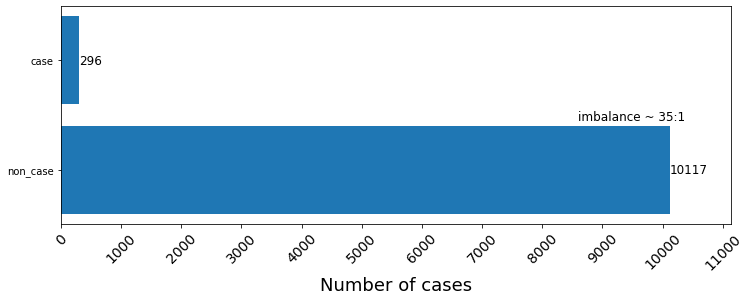

In [10]:
plot_imbalance(dataset)

In [11]:
majority_class = 0
near_u = 0
smote = 0.15
scaler = 'minmax'
weight_multiplier = 2
years_to_remove = [2010,2014,2015,2016,2017,2020,2021,2022]
#years_to_remove = []

features_to_remove = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 
                      'lc_prop1_assessment','lc_prop2_assessment','lc_prop3_assessment',
                      'lw', 'qc','lc_type1', 'lc_type3', 'lc_type4', 'lc_type5',]

#features_to_remove = []

In [12]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                        + features_to_remove).columns

print(feature_names)

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
       'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')


In [13]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, scaler, majority_class, features_to_remove)
        
    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)

    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

shap_values= np.concatenate(model_shaps, axis=0)

Year: 2010 || w0:1, w1:24 || ##
Year: 2011 || w0:1, w1:22 || ##
Year: 2012 || w0:1, w1:22 || ##
Year: 2013 || w0:1, w1:22 || ##
Year: 2014 || w0:1, w1:24 || ##
Year: 2015 || w0:1, w1:24 || ##
Year: 2016 || w0:1, w1:24 || ##
Year: 2017 || w0:1, w1:24 || ##
Year: 2018 || w0:1, w1:40 || ##
Year: 2019 || w0:1, w1:20 || ##
Year: 2020 || w0:1, w1:24 || ##
Year: 2021 || w0:1, w1:24 || ##
Year: 2022 || w0:1, w1:24 || ##


In [14]:
feature_names

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
       'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')

In [15]:
len(feature_names)

48

In [40]:
indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi',
            'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
            'ndvi_std','ndmi_std', 'ndwi_std', 'ndbi_std',]

weather = ['lst', 'lst_day', 'lst_night',
               'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
               'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
               'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',]

demographic = ['area', 'population', 'population_density',]

geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
                    'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
                    'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',]

spatiotemporal = ['month_sin', 'month_cos', 'week_sin', 'week_cos','eq_distance',]

entomological = ['mosq_pred', 'mosq_previous']

In [41]:
len(indicies+weather+demographic+geomorphological+spatiotemporal+entomological)

48

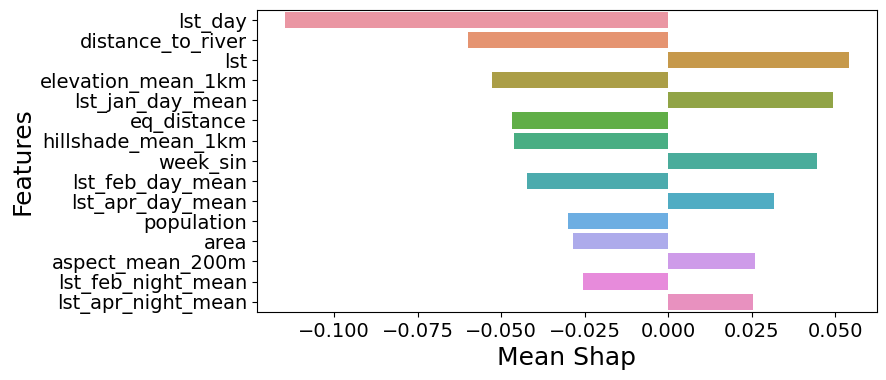

In [18]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

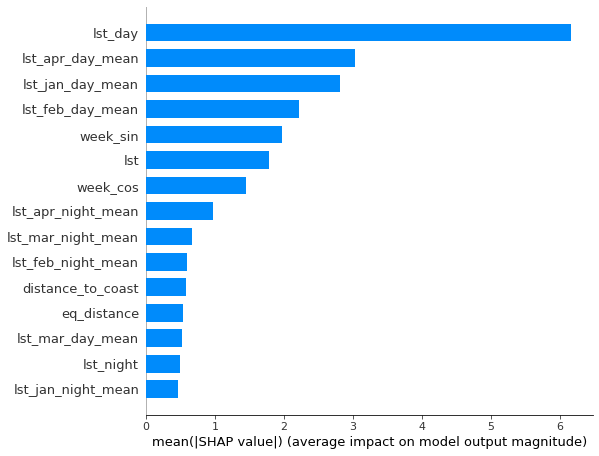

In [19]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

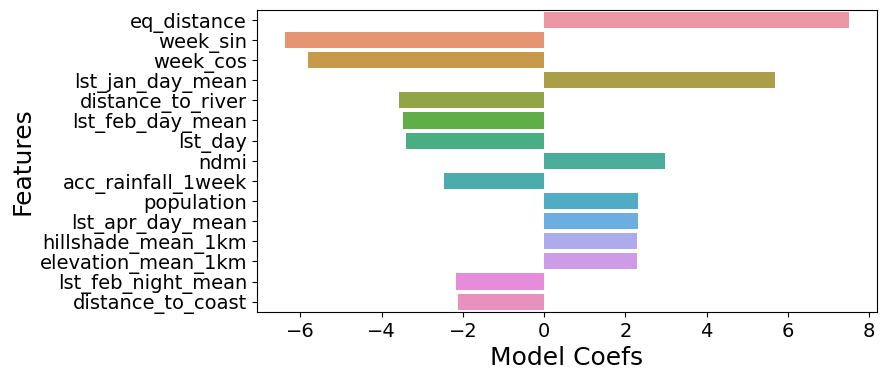

In [20]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

In [21]:
coefs

,features,weights
7,eq_distance,7.496406
2,week_sin,-6.380398
3,week_cos,-5.812744
23,lst_jan_day_mean,5.675277
35,distance_to_river,-3.565093
25,lst_feb_day_mean,-3.467473
21,lst_day,-3.409055
9,ndmi,2.978341
31,acc_rainfall_1week,-2.465948
5,population,2.323536


In [22]:
shaps

,features,weights,weights_abs
21,lst_day,-0.114747,0.114747
35,distance_to_river,-0.060019,0.060019
20,lst,0.054017,0.054017
38,elevation_mean_1km,-0.052773,0.052773
23,lst_jan_day_mean,0.049349,0.049349
7,eq_distance,-0.046759,0.046759
39,hillshade_mean_1km,-0.046146,0.046146
2,week_sin,0.044461,0.044461
25,lst_feb_day_mean,-0.042338,0.042338
29,lst_apr_day_mean,0.031772,0.031772


,features,weights
1,weather,0.030557
4,spatiotemporal,0.022458
2,demographic,0.020234
3,geomorphological,0.019792
0,rs_indicies,0.006902
5,entomological,0.002944


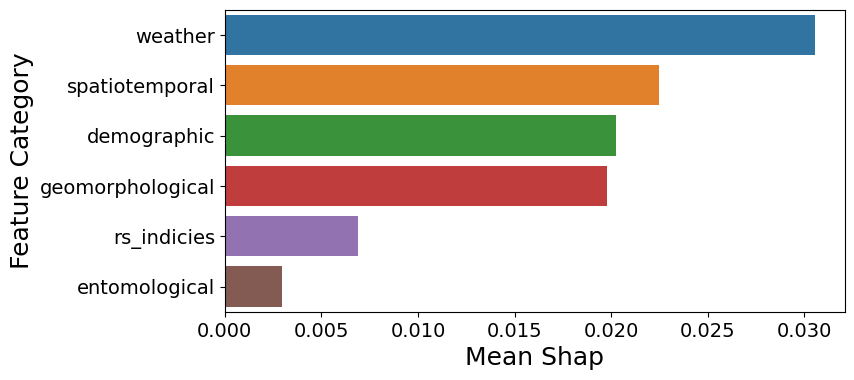

In [42]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_weather = shaps.loc[shaps['features'].isin(weather)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_entomological = shaps.loc[shaps['features'].isin(entomological)].drop(columns=['weights'])

categories = {'Category': ['rs_indicies', 'weather', 'demographic', 'geomorphological', 'spatiotemporal', 'entomological'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_weather.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_entomological.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,6)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

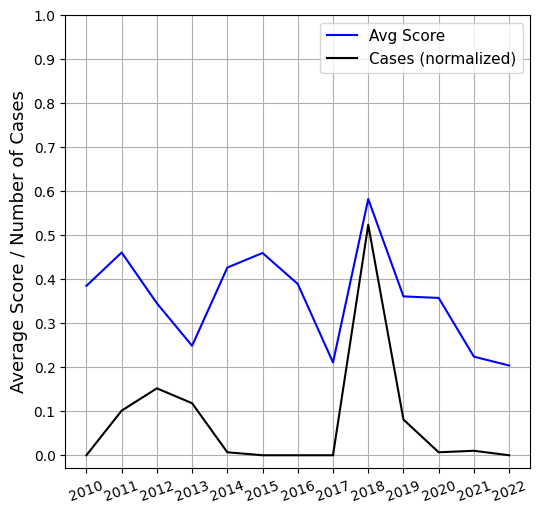

In [24]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

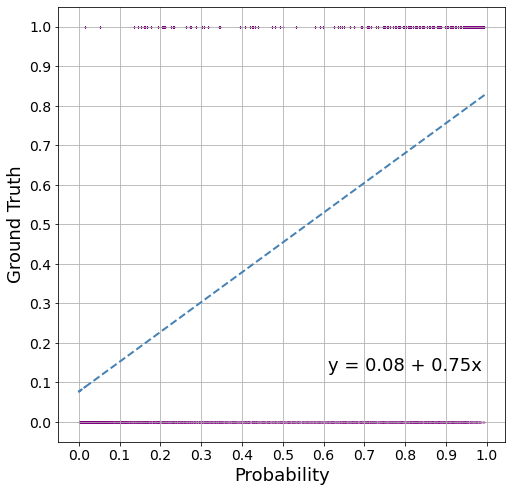

(0.07685218048713963, 0.7547824270724145)

In [25]:
plot_probability_curve(results_test)

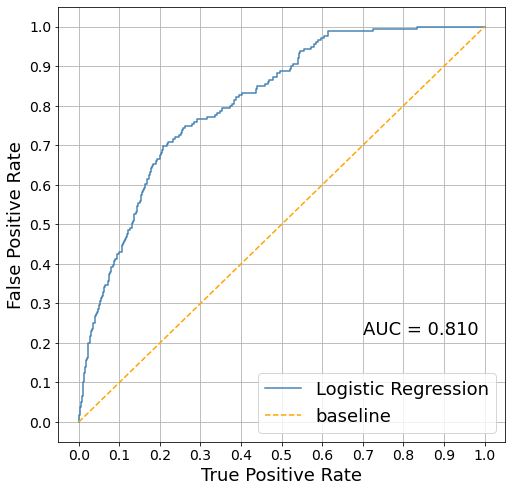

(0.2193, 0.7095, 0.6909, 0.7442)

In [26]:
plot_roc_curve(results_test)

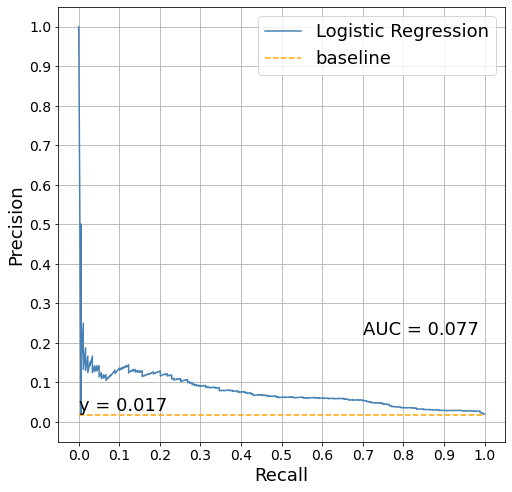

(0.4078, 0.08, 0.87, 0.2196)

In [39]:
plot_pr_curve(results_test, plot_fbeta = False)

In [28]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 5, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 13.73%
Weighted Average: 8.23%

Random Average: 9.80%
Random Weighted Average: 12.60%


In [29]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/05/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
1,16/05/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
2,01/06/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
3,16/06/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
4,01/07/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
151,16/08/2022,0,0,0.0,0,NaN,NaN,NaN,NaN
152,01/09/2022,0,0,0.0,0,NaN,NaN,NaN,NaN
153,16/09/2022,0,0,0.0,0,NaN,NaN,NaN,NaN
154,01/10/2022,0,0,0.0,0,NaN,NaN,NaN,NaN


In [30]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,0,0,0.00,0,nan %,NaN,nan %,NaN
1,2011,21,2,1.53,21,9.52 %,0.0952,7.29 %,0.0729
2,2012,22,1,1.67,17,5.88 %,0.0588,9.82 %,0.0982
3,2013,28,0,2.06,23,0.00 %,0.0000,8.96 %,0.0896
4,2014,2,1,0.20,2,50.00 %,0.5000,10.00 %,0.1000
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,85,4,6.21,36,11.11 %,0.1111,17.25 %,0.1725
9,2019,16,0,1.03,16,0.00 %,0.0000,6.44 %,0.0644


In [31]:
report_train, report_test = classification_report_new(results_train, results_test, threshold = 0.2, beta = 4)

In [32]:
report_train

,Accuracy,Precision,Recall,F4 Score,Loss
0,0.7298,0.0943,0.9897,0.635,0.5986


In [33]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,0.0000,0.5821,0.4179,0.0000,0.0000,0.0000,0.7658
1,2011,21.0000,0.5833,0.6895,0.0433,0.9524,0.4261,1.0390
2,2012,22.0000,0.5341,0.7162,0.0496,0.9545,0.4606,0.6465
3,2013,28.0000,0.4381,0.6802,0.0634,0.7857,0.4704,0.4057
4,2014,2.0000,0.6465,0.6772,0.0039,1.0000,0.0625,0.7931
5,2015,0.0000,0.6869,0.3131,0.0000,0.0000,0.0000,0.8954
6,2016,0.0000,0.6301,0.3699,0.0000,0.0000,0.0000,0.6878
7,2017,0.0000,0.3914,0.6086,0.0000,0.0000,0.0000,0.3031
8,2018,85.0000,0.7588,0.6219,0.1381,0.9765,0.7195,1.2426
9,2019,16.0000,0.5568,0.6943,0.0340,0.9375,0.3659,0.6328


In [34]:
results_test

,lau1,day,month,year,case,score
0,παλαιου φαληρου,16,7,2018,0,9.942738e-01
1,ελευσινας,16,7,2018,1,9.933459e-01
2,αθηναιων,16,8,2010,0,9.930126e-01
3,παλαιου φαληρου,1,8,2018,0,9.929982e-01
4,παλαιου φαληρου,16,8,2018,0,9.925220e-01
...,...,...,...,...,...,...
10291,σπετσων,16,10,2018,0,2.221992e-16
10292,σπετσων,16,5,2018,0,1.709042e-16
10293,σπετσων,1,10,2018,0,8.913249e-17
10294,σπετσων,1,5,2018,0,4.702777e-17


In [35]:
results_test[['lau1', 'day', 'month', 'year']].value_counts()

lau1             day  month  year
αγιας βαρβαρας   1    5      2010    1
παλαιου φαληρου  1    9      2011    1
παιανιας         16   10     2018    1
                             2019    1
                             2020    1
                                    ..
ηλιουπολεως      1    5      2011    1
                             2012    1
                             2013    1
                             2014    1
ωρωπου           16   10     2022    1
Length: 10296, dtype: int64

In [36]:
# results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2010-2022.csv", encoding = enc, index = False)

In [37]:
data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

object_cols = data_train.select_dtypes(include=['object']).columns.to_list()
removed_cols = features_to_remove

X_train = data_train.drop(columns = ['case'] + object_cols + removed_cols)
y_train = data_train['case']

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
           
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_value_counts = y_train.value_counts()
class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        
if (near_u != 0):
    if majority_class == 0:
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    elif majority_class == 1:
        nm = NearMiss(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 - near_u))}, version = 1, n_jobs = -1)

    X_train_resampled, y_train_resampled = nm.fit_resample(X_train_imputed, y_train)

    y_train_value_counts = y_train_resampled.value_counts()
    class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
    class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        

if (smote != 0):
    if majority_class == 0:
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    elif majority_class == 1:
        sm = BorderlineSMOTE(sampling_strategy = {0: math.ceil(class_0_counts * (1 + smote)), 1: class_1_counts}, n_jobs = -1, random_state = 0)

    if (near_u != 0):
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_resampled, y_train_resampled)
    else:
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_imputed, y_train)

X_train_returned = X_train_imputed if (near_u == 0 and smote == 0) else X_train_resampled
y_train_returned = y_train if (near_u == 0 and smote == 0) else y_train_resampled

value_counts = y_train_returned.value_counts()
non_cases = value_counts.get(key = 0) if value_counts.get(key = 0) is not None else 0
cases = value_counts.get(key = 1) if value_counts.get(key = 1) is not None else 0
        
if non_cases >= cases:
    w0 = 1
    try:
        w1 = math.ceil(non_cases/cases)
    except ZeroDivisionError:
        w1 = 10
else:
    w1 = 1
    try:
        w0 = math.ceil(cases/non_cases)
    except ZeroDivisionError:
        w0 = 10
            
w1 = w1*weight_multiplier

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

model.fit(X_train_returned, y_train_returned)

model

LogisticRegression(class_weight={0.0: 1, 1.0: 24}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [38]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model_new.pkl', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Imputer_new.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Scaler_new.pkl', 'wb'))